# Final CME Candidate Selection and CACTus Validation

This notebook identifies short-duration CME-like transients from the CIR-cleaned DSN scintillation signal and evaluates whether the resulting candidates are consistent with independently detected CACTus CME events.

The workflow combines transient thresholding, candidate merging, local background diagnostics, line-of-sight geometry, and CACTus propagation consistency checks to construct the final DSN CME candidate catalogue.

---

## Workflow

### SECTION 1 — Load CIR-Cleaned DSN Scintillation Windows

1. Load CIR-cleaned phase scintillation windows
2. Validate required columns
3. Sort windows chronologically
4. Inspect clean-signal statistics

---

### SECTION 2 — Add Line-of-Sight Geometry

1. Construct Earth–VEX geometry grid
2. Compute projected pierce-point geometry
3. Interpolate geometry onto DSN windows
4. Inspect pierce-point distance, longitude, and latitude

---

### SECTION 3 — Detect Final CME-Like Candidates

1. Apply transient threshold to CIR-cleaned signal
2. Identify consecutive elevated windows
3. Enforce duration constraints
4. Merge nearby transient intervals
5. Compute event-level geometry summaries

---

### SECTION 4 — Candidate / Background Diagnostics

1. Compute local event/background contrast
2. Measure candidate duration statistics
3. Compute peak and median clean-signal metrics
4. Evaluate candidate consistency

---

### SECTION 5 — CACTus CME Consistency Check

1. Load yearly CACTus CME catalogue
2. Propagate CACTus events radially
3. Compare CME fronts with event pierce-point distance
4. Evaluate angular consistency
5. Flag DSN candidates consistent with CACTus events

---

### SECTION 6 — Export PRIDE Validation Table

1. Select DSN/CACTus event columns needed for PRIDE comparison
2. Save CACTus-matched candidate table
3. Inspect exported validation table

---

### SECTION 7 — Final Candidate Visualisation

1. Plot CIR-cleaned DSN response
2. Overlay transient candidate intervals
3. Highlight CACTus-supported events
4. Compare supported and unsupported candidate populations

---

### SECTION 8 — Save Final Candidate Products

1. Save final CME candidate table
2. Save candidate/background diagnostic table
3. Save final candidate figure

---

## Outputs

This notebook produces:

- `final_cme_candidates_<year>.csv`
- `final_cme_candidate_contrast_<year>.csv`
- `dsn_cactus_events_for_pride_<year>.csv`
- `final_cme_candidates_<year>.png`

These outputs form the final transient-event catalogue used for PRIDE validation and multi-year statistical analysis.

In [1]:
#!pip install astroquery

In [2]:
# ============================================================
# SECTION 0 — Setup
# ============================================================

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
# ============================================================
# Configuration
# ============================================================

YEAR = "2014"

debug = True
save_files = False

settings = importlib.import_module(f"config.settings_{YEAR}")

for k in dir(settings):
    if not k.startswith("_"):
        globals()[k] = getattr(settings, k)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / YEAR

INPUT_FILE = OUTPUT_DIR / f"phase_windows_detected_{YEAR}.csv"
OUTPUT_FILE = OUTPUT_DIR / f"final_cme_candidates_{YEAR}.csv"
CHECK_FILE = OUTPUT_DIR / f"final_cme_candidate_contrast_{YEAR}.csv"
FIG_FILE = OUTPUT_DIR / f"final_cme_candidates_{YEAR}.png"
EVENTS_FOR_PRIDE_FILE = OUTPUT_DIR / f"dsn_cactus_events_for_pride_{YEAR}.csv"

CACTUS_FILE = PROJECT_ROOT / "inputs" / f"cactus_cmes_{YEAR}.csv"

from src.geometry_utils import (
    build_vex_earth_p_point_geometry_grid,
    add_projected_p_point_geometry,
)

from src.detection_utils import (
    FinalCMEConfig,
    load_final_cme_input,
    detect_final_cme_candidates,
    compute_final_cme_contrast,
    add_event_median_columns,
    match_cactus_to_dsn_candidates,
)

from src.plot_utils import plot_final_cme_candidates

if debug:
    print("YEAR:", YEAR)
    print("PROJECT_ROOT:", PROJECT_ROOT)
    print("OUTPUT_DIR:", OUTPUT_DIR)
    print("INPUT_FILE:", INPUT_FILE)
    print("CACTUS_FILE:", CACTUS_FILE)

YEAR: 2014
PROJECT_ROOT: /mnt/data/jhub/16-VenusExpres/dsn_multi_year
OUTPUT_DIR: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014
INPUT_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_windows_detected_2014.csv
CACTUS_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/inputs/cactus_cmes_2014.csv


In [4]:
# ============================================================
# SECTION 1 — Final CME-Candidate Settings
# ============================================================

final_cme_config = FinalCMEConfig(
    threshold=3.0,
    min_consec_windows=2,
    min_duration_hr=0.33,
    max_duration_hr=12.0,
    merge_gap_hr=0.67,
    local_background_hr=12.0,
)

if debug:
    print(final_cme_config)

FinalCMEConfig(threshold=3.0, min_consec_windows=2, min_duration_hr=0.33, max_duration_hr=12.0, merge_gap_hr=0.67, local_background_hr=12.0)


In [5]:
# ============================================================
# SECTION 2 — Load CIR-Cleaned DSN Window Table
# ============================================================

windows_df = load_final_cme_input(INPUT_FILE)

if debug:
    print("Rows:", len(windows_df))
    print("Time range:", windows_df["mid"].min(), "→", windows_df["mid"].max())
    print(
        "Clean signal range:",
        windows_df["clean_signal"].min(),
        "→",
        windows_df["clean_signal"].max(),
    )

    display(windows_df.head())

Rows: 4065
Time range: 2014-01-01 10:17:50 → 2014-06-04 16:47:50
Clean signal range: 0.1727634739630628 → 20.721715516872163


,start,end,mid,phase_rms_rad,n_samples,day,elongation_deg,phase_expected,phase_ratio,phase_smooth,clean_signal,event_flag
0,2014-01-01 10:07:50,2014-01-01 10:27:50,2014-01-01 10:17:50,2.297264,120,2014-01-01,16.6007,0.346279,6.634133,1.233473,5.378420,True
1,2014-01-01 10:17:50,2014-01-01 10:37:50,2014-01-01 10:27:50,1.239110,120,2014-01-01,16.6007,0.346279,3.578352,1.200665,2.980310,False
2,2014-01-01 10:27:50,2014-01-01 10:47:50,2014-01-01 10:37:50,0.465645,120,2014-01-01,16.6007,0.346279,1.344709,1.172485,1.146888,False
3,2014-01-01 10:37:50,2014-01-01 10:57:50,2014-01-01 10:47:50,0.378426,120,2014-01-01,16.6007,0.346279,1.092836,1.144305,0.955021,False
4,2014-01-01 10:47:50,2014-01-01 11:07:50,2014-01-01 10:57:50,0.673374,120,2014-01-01,16.6007,0.346279,1.944598,1.172485,1.658527,False


In [6]:
# ============================================================
# SECTION 3 — Add LOS Closest-Approach Geometry
# ============================================================

geom_start = windows_df["mid"].min() - pd.Timedelta(hours=1)
geom_stop = windows_df["mid"].max() + pd.Timedelta(hours=1)

geom_grid = build_vex_earth_p_point_geometry_grid(
    start=geom_start,
    stop=geom_stop,
    step="10m",
)

windows_df = add_projected_p_point_geometry(
    windows_df,
    geom_grid,
    mid_col="mid",
)

if debug:
    print("Geometry rows:", len(geom_grid))
    print(
        "Geometry time range:",
        geom_grid["time"].min(),
        "→",
        geom_grid["time"].max(),
    )

    print(
        "P-point range AU:",
        windows_df["p_point_AU"].min(),
        "→",
        windows_df["p_point_AU"].max(),
    )

    print(
        "P-point longitude range:",
        windows_df["p_lon_deg"].min(),
        "→",
        windows_df["p_lon_deg"].max(),
    )

    print(
        "P-point latitude range:",
        windows_df["p_lat_deg"].min(),
        "→",
        windows_df["p_lat_deg"].max(),
    )

    display(
        windows_df[
            ["mid", "p_point_AU", "p_lon_deg", "p_lat_deg", "los_length_AU"]
        ].head()
    )

Geometry rows: 22228
Geometry time range: 2014-01-01 09:17:50+00:00 → 2014-06-04 17:47:50+00:00
P-point range AU: 0.6003042220669816 → 0.7239303374361847
P-point longitude range: 94.66723403424385 → 307.46554094516364
P-point latitude range: -2.7560552730443506 → 3.3773749730207823


,mid,p_point_AU,p_lon_deg,p_lat_deg,los_length_AU
0,2014-01-01 10:17:50+00:00,0.719214,94.667234,1.034691,0.279095
1,2014-01-01 10:27:50+00:00,0.719212,94.678458,1.034531,0.279077
2,2014-01-01 10:37:50+00:00,0.719210,94.689686,1.034394,0.279060
3,2014-01-01 10:47:50+00:00,0.719208,94.700918,1.034279,0.279042
4,2014-01-01 10:57:50+00:00,0.719206,94.712153,1.034184,0.279024


In [7]:
# ============================================================
# SECTION 4 — Detect Final CME-Like Candidates
# ============================================================

windows_flagged, final_events = detect_final_cme_candidates(
    windows_df,
    year=YEAR,
    config=final_cme_config,
)

windows_flagged["mid"] = pd.to_datetime(
    windows_flagged["mid"],
    utc=True,
)

windows_df["mid"] = pd.to_datetime(
    windows_df["mid"],
    utc=True,
)

for c in ["start", "end", "mid"]:
    if c in final_events.columns:
        final_events[c] = pd.to_datetime(
            final_events[c],
            utc=True,
        )

if debug:
    print("Final CME-like candidates:", len(final_events))
    display(final_events)

# ============================================================
# SECTION 4.5 — Add Event-Level Geometry Summaries
# ============================================================

final_events = add_event_median_columns(
    final_events,
    windows_df,
    columns=[
        "p_point_AU",
        "p_lon_deg",
        "p_lat_deg",
    ],
)

if debug and not final_events.empty:
    display(
        final_events[
            [
                "event_id",
                "p_point_AU_median",
                "p_lon_deg_median",
                "p_lat_deg_median",
            ]
        ]
    )

Final CME-like candidates: 8


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,median_phase_rms_rad,elongation_deg_median,p_point_AU_median
0,1,2014,2014-01-02 10:07:50+00:00,2014-01-02 10:37:50+00:00,2014-01-02 10:22:50+00:00,0.500000,2,5.935752,4.660562,2.339155,1.836629,15.2220,0.719130
1,2,2014,2014-01-08 09:57:50+00:00,2014-01-08 10:27:50+00:00,2014-01-08 10:12:50+00:00,0.500000,2,3.282327,3.164601,1.113386,1.049763,7.1476,0.718708
2,3,2014,2014-01-24 10:47:50+00:00,2014-01-24 11:17:50+00:00,2014-01-24 11:02:50+00:00,0.500000,2,4.354571,4.070721,1.874883,1.752670,20.2046,0.718254
3,4,2014,2014-02-01 08:07:50+00:00,2014-02-01 08:37:50+00:00,2014-02-01 08:22:50+00:00,0.500000,2,3.591409,3.358163,1.867863,1.756761,29.2292,0.718410
4,5,2014,2014-02-03 06:47:50+00:00,2014-02-03 07:17:50+00:00,2014-02-03 07:02:50+00:00,0.500000,2,5.993302,4.643548,2.427390,1.855042,31.0996,0.718498
5,6,2014,2014-02-06 06:57:50+00:00,2014-02-06 07:27:50+00:00,2014-02-06 07:12:50+00:00,0.500000,2,3.619539,3.326862,2.731495,2.510626,33.6260,0.718640
6,7,2014,2014-02-23 09:37:50+00:00,2014-02-23 10:27:50+00:00,2014-02-23 10:02:50+00:00,0.833333,4,4.365627,3.992019,2.432699,2.224510,42.7372,0.720059
7,8,2014,2014-05-31 07:47:50+00:00,2014-05-31 08:17:50+00:00,2014-05-31 08:02:50+00:00,0.500000,2,20.721716,12.600032,22.227667,14.074856,37.2771,0.613250


,event_id,p_point_AU_median,p_lon_deg_median,p_lat_deg_median
0,1,0.719130,96.290834,1.124991
1,2,0.718708,105.996931,1.646298
2,3,0.718254,132.028785,2.767332
3,4,0.718410,144.853787,3.132424
4,5,0.718497,148.019972,3.202374
5,6,0.718640,152.902189,3.281803
6,7,0.720059,180.679705,3.264564
7,8,0.613250,302.344701,-2.676036


In [8]:
# ============================================================
# SECTION 5 — Candidate / Background Diagnostics
# ============================================================

diagnostics_df = compute_final_cme_contrast(
    windows_flagged,
    final_events,
)

if debug:

    display(diagnostics_df.head(10))

    print(
        "Median contrast ratio:",
        diagnostics_df["contrast_ratio"].median(),
    )

    print(
        "Minimum contrast ratio:",
        diagnostics_df["contrast_ratio"].min(),
    )

    print(
        "Maximum contrast ratio:",
        diagnostics_df["contrast_ratio"].max(),
    )

,event_id,inside_median,outside_median,contrast_ratio
0,1,3.015473,0.913393,3.301396
1,2,2.656232,0.941985,2.819825
2,3,3.167523,0.899459,3.521588
3,4,2.269744,1.048988,2.163746
4,5,3.293794,1.031786,3.192323
5,6,2.601751,1.036736,2.509560
6,7,3.525313,1.450730,2.430027
7,8,3.044487,0.993526,3.064326


Median contrast ratio: 2.9420754644198435
Minimum contrast ratio: 2.1637459758522084
Maximum contrast ratio: 3.5215877303508587


In [9]:
# ============================================================
# SECTION 6 — Load CACTus Catalogue
# ============================================================

cactus_df = pd.read_csv(CACTUS_FILE)

cactus_df["t0"] = pd.to_datetime(
    cactus_df["t0"],
    utc=True,
    errors="coerce",
)

for c in ["start", "end", "mid"]:
    if c in final_events.columns:
        final_events[c] = pd.to_datetime(
            final_events[c],
            utc=True,
            errors="coerce",
        )

if debug:
    print("CACTus rows:", len(cactus_df))
    print("CACTus time range:", cactus_df["t0"].min(), "→", cactus_df["t0"].max())
    display(cactus_df.head())

CACTus rows: 1855
CACTus time range: 2014-01-01 03:12:00+00:00 → 2014-12-31 17:12:00+00:00


,month,cme_id,t0,dt0_hr,pa_deg,da_deg,v_km_s,dv_km_s,minv_km_s,maxv_km_s,halo_flag,source_url
0,1,176,2014-01-31 16:24:00+00:00,2,352,118,484,127,202,664,II,https://www.sidc.be/cactus/catalog/LASCO/2_5_0...
1,1,175,2014-01-31 16:02:00+00:00,1,111,12,326,52,246,372,NaN,https://www.sidc.be/cactus/catalog/LASCO/2_5_0...
2,1,174,2014-01-31 08:12:00+00:00,1,330,6,211,108,177,422,NaN,https://www.sidc.be/cactus/catalog/LASCO/2_5_0...
3,1,173,2014-01-31 06:12:00+00:00,1,168,18,551,117,446,781,NaN,https://www.sidc.be/cactus/catalog/LASCO/2_5_0...
4,1,172,2014-01-31 03:12:00+00:00,2,203,44,367,136,229,642,NaN,https://www.sidc.be/cactus/catalog/LASCO/2_5_0...


In [10]:
# ============================================================
# SECTION 7 — CACTus Consistency Check
# ============================================================

if "los_pa_deg_median" in final_events.columns:
    EVENT_ANGLE_COL = "los_pa_deg_median"

elif "p_lon_deg_median" in final_events.columns:
    EVENT_ANGLE_COL = "p_lon_deg_median"

else:
    EVENT_ANGLE_COL = None

final_events = match_cactus_to_dsn_candidates(
    final_events,
    cactus_df,
    p_col="p_point_AU_median",
    event_angle_col=EVENT_ANGLE_COL,
    radial_tolerance_AU=0.20,
    angle_tolerance_deg=15.0,
)

if debug:
    print("Using event angle column:", EVENT_ANGLE_COL)

    print("\nCACTus crossing counts:")
    print(final_events["cactus_crosses_p_point"].value_counts(dropna=False))

    print("\nCACTus direction consistency counts:")
    print(final_events["cactus_direction_consistent"].value_counts(dropna=False))

    display(final_events)

Using event angle column: p_lon_deg_median

CACTus crossing counts:
cactus_crosses_p_point
True     5
False    3
Name: count, dtype: int64

CACTus direction consistency counts:
cactus_direction_consistent
True     5
False    3
Name: count, dtype: int64


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,...,matched_cactus_launch_utc,matched_cactus_speed_kms,matched_cactus_pa_deg,matched_cactus_width_deg,matched_cactus_half_width_deg,cactus_predicted_distance_AU,cactus_radial_error_AU,event_angle_deg,cactus_angle_error_deg,cactus_angle_allowed_deg
0,1,2014,2014-01-02 10:07:50+00:00,2014-01-02 10:37:50+00:00,2014-01-02 10:22:50+00:00,0.500000,2,5.935752,4.660562,2.339155,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2014,2014-01-08 09:57:50+00:00,2014-01-08 10:27:50+00:00,2014-01-08 10:12:50+00:00,0.500000,2,3.282327,3.164601,1.113386,...,2014-01-05 15:48:00+00:00,362.0,98.0,10.0,5.0,0.578555,0.140153,105.996931,7.996931,20.0
2,3,2014,2014-01-24 10:47:50+00:00,2014-01-24 11:17:50+00:00,2014-01-24 11:02:50+00:00,0.500000,2,4.354571,4.070721,1.874883,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2014,2014-02-01 08:07:50+00:00,2014-02-01 08:37:50+00:00,2014-02-01 08:22:50+00:00,0.500000,2,3.591409,3.358163,1.867863,...,2014-01-30 15:48:00+00:00,781.0,148.0,214.0,107.0,0.762687,0.044277,144.853787,3.146213,122.0
4,5,2014,2014-02-03 06:47:50+00:00,2014-02-03 07:17:50+00:00,2014-02-03 07:02:50+00:00,0.500000,2,5.993302,4.643548,2.427390,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,2014,2014-02-06 06:57:50+00:00,2014-02-06 07:27:50+00:00,2014-02-06 07:12:50+00:00,0.500000,2,3.619539,3.326862,2.731495,...,2014-02-03 21:36:00+00:00,452.0,166.0,26.0,13.0,0.626675,0.091965,152.902189,13.097811,28.0
6,7,2014,2014-02-23 09:37:50+00:00,2014-02-23 10:27:50+00:00,2014-02-23 10:02:50+00:00,0.833333,4,4.365627,3.992019,2.432699,...,2014-02-20 03:12:00+00:00,383.0,197.0,44.0,22.0,0.726712,0.006652,180.679705,16.320295,37.0
7,8,2014,2014-05-31 07:47:50+00:00,2014-05-31 08:17:50+00:00,2014-05-31 08:02:50+00:00,0.500000,2,20.721716,12.600032,22.227667,...,2014-05-25 01:25:00+00:00,146.0,309.0,8.0,4.0,0.529228,0.084022,302.344701,6.655299,19.0


In [11]:
# ============================================================
# SECTION 8 — Save DSN/CACTus-Matched Events for PRIDE
# ============================================================

cols_for_pride = [
    "event_id",
    "year",
    "start",
    "end",
    "mid",
    "duration_hr",
    "n_windows",
    "peak_clean_signal",
    "median_clean_signal",
    "peak_phase_rms_rad",
    "p_point_AU_median",
    "event_angle_deg",
    "cactus_crosses_p_point",
    "cactus_direction_consistent",
    "matched_cactus_launch_utc",
    "matched_cactus_speed_kms",
    "matched_cactus_pa_deg",
    "matched_cactus_width_deg",
    "cactus_predicted_distance_AU",
    "cactus_radial_error_AU",
    "cactus_angle_error_deg",
    "cactus_angle_allowed_deg",
]

cols_for_pride = [
    c for c in cols_for_pride
    if c in final_events.columns
]

events_for_pride = final_events[cols_for_pride].copy()

if save_files:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    events_for_pride.to_csv(
        EVENTS_FOR_PRIDE_FILE,
        index=False,
    )

    print("Saved:", EVENTS_FOR_PRIDE_FILE)

display(events_for_pride)

,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,...,cactus_crosses_p_point,cactus_direction_consistent,matched_cactus_launch_utc,matched_cactus_speed_kms,matched_cactus_pa_deg,matched_cactus_width_deg,cactus_predicted_distance_AU,cactus_radial_error_AU,cactus_angle_error_deg,cactus_angle_allowed_deg
0,1,2014,2014-01-02 10:07:50+00:00,2014-01-02 10:37:50+00:00,2014-01-02 10:22:50+00:00,0.500000,2,5.935752,4.660562,2.339155,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2014,2014-01-08 09:57:50+00:00,2014-01-08 10:27:50+00:00,2014-01-08 10:12:50+00:00,0.500000,2,3.282327,3.164601,1.113386,...,True,True,2014-01-05 15:48:00+00:00,362.0,98.0,10.0,0.578555,0.140153,7.996931,20.0
2,3,2014,2014-01-24 10:47:50+00:00,2014-01-24 11:17:50+00:00,2014-01-24 11:02:50+00:00,0.500000,2,4.354571,4.070721,1.874883,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2014,2014-02-01 08:07:50+00:00,2014-02-01 08:37:50+00:00,2014-02-01 08:22:50+00:00,0.500000,2,3.591409,3.358163,1.867863,...,True,True,2014-01-30 15:48:00+00:00,781.0,148.0,214.0,0.762687,0.044277,3.146213,122.0
4,5,2014,2014-02-03 06:47:50+00:00,2014-02-03 07:17:50+00:00,2014-02-03 07:02:50+00:00,0.500000,2,5.993302,4.643548,2.427390,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,2014,2014-02-06 06:57:50+00:00,2014-02-06 07:27:50+00:00,2014-02-06 07:12:50+00:00,0.500000,2,3.619539,3.326862,2.731495,...,True,True,2014-02-03 21:36:00+00:00,452.0,166.0,26.0,0.626675,0.091965,13.097811,28.0
6,7,2014,2014-02-23 09:37:50+00:00,2014-02-23 10:27:50+00:00,2014-02-23 10:02:50+00:00,0.833333,4,4.365627,3.992019,2.432699,...,True,True,2014-02-20 03:12:00+00:00,383.0,197.0,44.0,0.726712,0.006652,16.320295,37.0
7,8,2014,2014-05-31 07:47:50+00:00,2014-05-31 08:17:50+00:00,2014-05-31 08:02:50+00:00,0.500000,2,20.721716,12.600032,22.227667,...,True,True,2014-05-25 01:25:00+00:00,146.0,309.0,8.0,0.529228,0.084022,6.655299,19.0


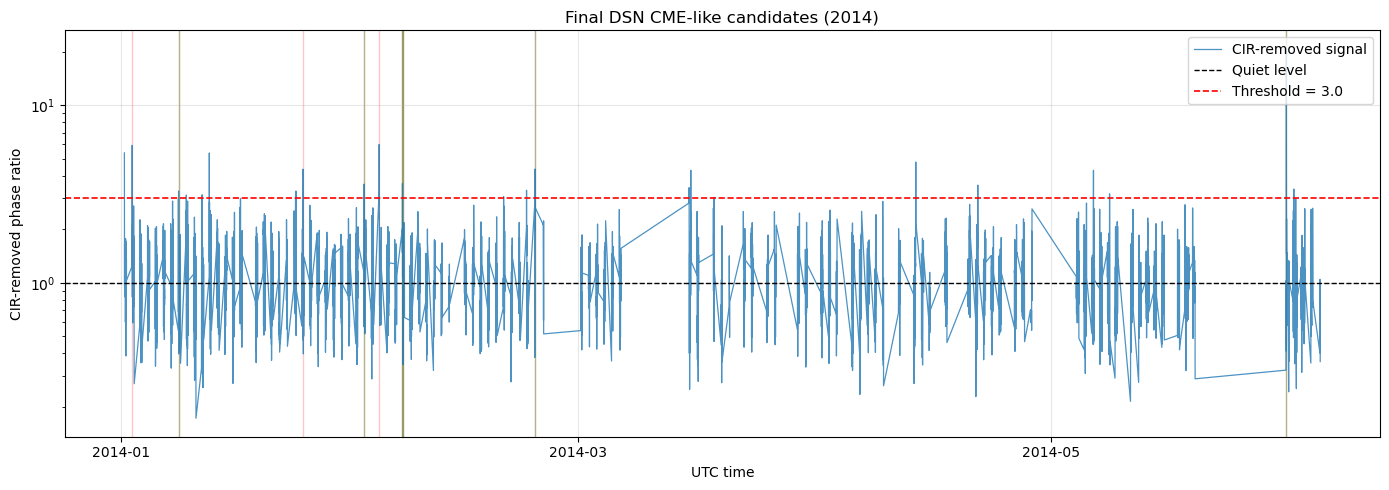

In [12]:
# ============================================================
# SECTION 9 — Final Candidate Visualisation
# ============================================================

fig, ax = plot_final_cme_candidates(
    windows_flagged,
    final_events,
    year=YEAR,
)

for _, e in final_events.iterrows():
    if e.get("cactus_crosses_p_point", False):
        ax.axvspan(
            e["start"],
            e["end"],
            color="green",
            alpha=0.3,
        )

plt.show()

if save_files:
    fig.savefig(
        FIG_FILE,
        dpi=300,
        bbox_inches="tight",
    )

    print("Saved:", FIG_FILE)

Supported events: 5
Unsupported events: 3
Supported duration: 0.5
Supported peak: 3.619538688300964
Supported median signal: 3.358162983527421
Supported contrast: 1.0879737180927953
Unsupported duration: 0.5
Unsupported peak: 5.935751928684949
Unsupported median signal: 4.643547777847751
Unsupported contrast: 1.273612829057896


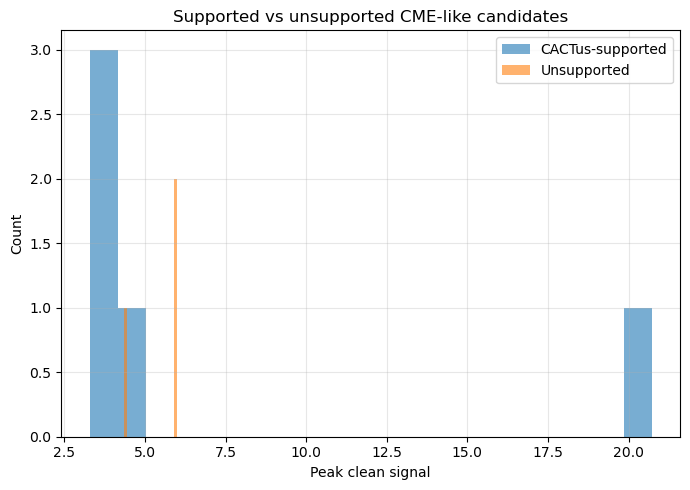

In [13]:
# ============================================================
# SECTION 10 — Supported vs Unsupported Candidate Diagnostics
# ============================================================

if "cactus_crosses_p_point" in final_events.columns:

    final_events["contrast"] = (
        final_events["peak_clean_signal"]
        / final_events["median_clean_signal"]
    )

    supported = final_events[
        final_events["cactus_crosses_p_point"] == True
    ].copy()

    unsupported = final_events[
        final_events["cactus_crosses_p_point"] == False
    ].copy()

    print("Supported events:", len(supported))
    print("Unsupported events:", len(unsupported))

    if len(supported) > 0:
        print("Supported duration:", supported["duration_hr"].median())
        print("Supported peak:", supported["peak_clean_signal"].median())
        print("Supported median signal:", supported["median_clean_signal"].median())
        print("Supported contrast:", supported["contrast"].median())

    if len(unsupported) > 0:
        print("Unsupported duration:", unsupported["duration_hr"].median())
        print("Unsupported peak:", unsupported["peak_clean_signal"].median())
        print("Unsupported median signal:", unsupported["median_clean_signal"].median())
        print("Unsupported contrast:", unsupported["contrast"].median())

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.hist(
        supported["peak_clean_signal"].dropna(),
        bins=20,
        alpha=0.6,
        label="CACTus-supported",
    )

    ax.hist(
        unsupported["peak_clean_signal"].dropna(),
        bins=20,
        alpha=0.6,
        label="Unsupported",
    )

    ax.set_xlabel("Peak clean signal")
    ax.set_ylabel("Count")
    ax.set_title("Supported vs unsupported CME-like candidates")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

In [14]:
# ============================================================
# SECTION 11 — Save Final Candidate Tables
# ============================================================

if save_files:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    final_events.to_csv(
        OUTPUT_FILE,
        index=False,
    )

    diagnostics_df.to_csv(
        CHECK_FILE,
        index=False,
    )

    print("Saved candidate table:", OUTPUT_FILE)
    print("Saved diagnostics table:", CHECK_FILE)